# Import Dependencies

In [2]:
import re
import nltk
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd

# Download tokenizer and English stop words
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Frans\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Frans\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Define Document

In [4]:
sentence2 = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

# Text Preprocessing

In [5]:
# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print("Tokenized sentences:")
for sent in sent_token2:
    print(sent)

# Initialize English stop words
english_stopwords = set(stopwords.words('english'))

def remove_english_stopwords(sentence):
    tokens = re.findall(r"[A-Za-z']+", sentence.lower())
    filtered_tokens = [token for token in tokens if token not in english_stopwords]
    return " ".join(filtered_tokens)

# Remove English stop words from each sentence
cleaned_sentences = [remove_english_stopwords(sent) for sent in sent_token2]
print("\nCleaned sentences (English stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)


Tokenized sentences:

Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
“We’ve shown over the past 12 months we are the best team in the world.
Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
“To win these five trophies – for me, the five biggest prizes available to us – is incredible.
I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
I couldn’t

In [6]:
# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()  # stop words are already removed in preprocessing
features = vectorizer.fit_transform(cleaned_sentences)

print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after English stop word removal):")
print(features.shape)

# To see the feature names (the words in the vocabulary after English stop word removal):
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after English stop word removal):")
print(feature_names)

# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF Feature Matrix (Sparse) on cleaned sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 256 stored elements and shape (20, 196)>
  Coords	Values
  (0, 101)	0.3303342590916475
  (0, 32)	0.24419783522831462
  (0, 98)	0.20823534147749018
  (0, 80)	0.20823534147749018
  (0, 192)	0.20823534147749018
  (0, 35)	0.3026045242569144
  (0, 193)	0.3660841050487077
  (0, 41)	0.3660841050487077
  (0, 26)	0.18304205252435385
  (0, 85)	0.16516712954582374
  (0, 194)	0.16516712954582374
  (0, 195)	0.18304205252435385
  (0, 7)	0.18304205252435385
  (0, 178)	0.20823534147749018
  (0, 47)	0.20823534147749018
  (0, 69)	0.18304205252435385
  (0, 191)	0.1513022621284572
  (0, 74)	0.20823534147749018
  (1, 35)	0.14791050371062428
  (1, 41)	0.357877559902148
  (1, 194)	0.16146456096485481
  (1, 4)	0.20356730834691508
  (1, 133)	0.178938779951074
  (1, 91)	0.357877559902148
  (1, 29)	0.20356730834691508
  :	:
  (17, 150)	0.19920981801471985
  (17, 22)	0.19920981801471985
  (17, 128)	

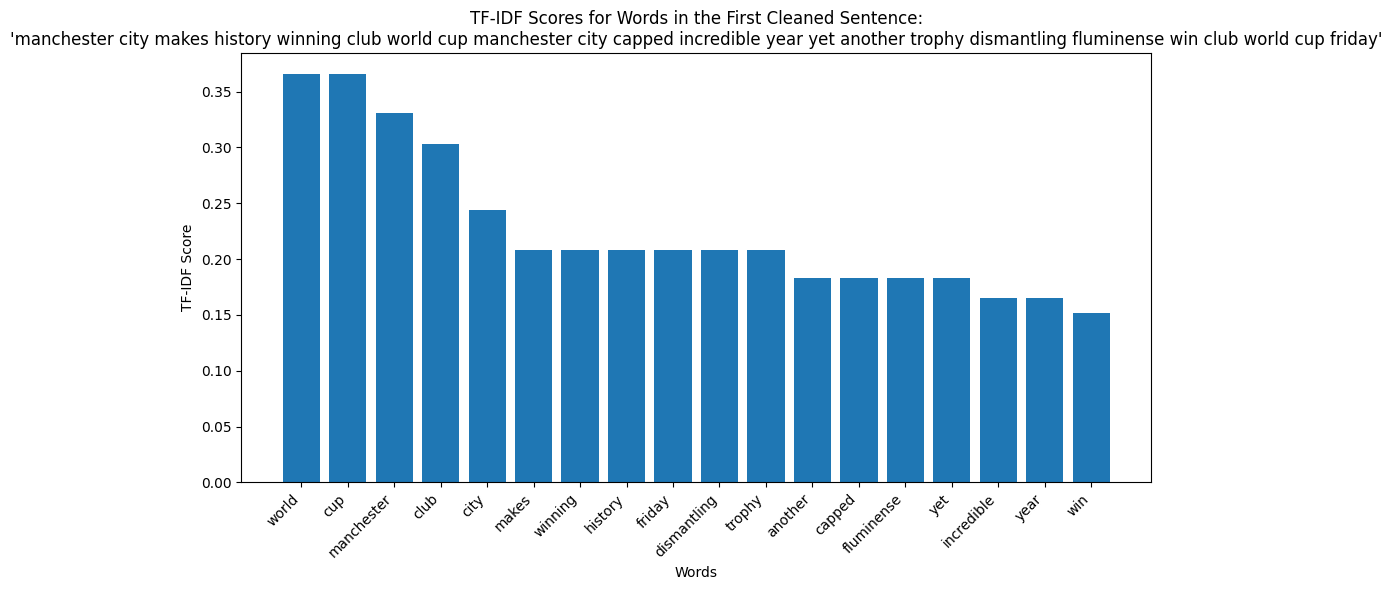

In [7]:

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

# Calculate Sentence Score

**List of Sentences:**
1. 
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
2. Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
3. The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
4. “We’ve shown over the past 12 months we are the best team in the world.
5. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
6. “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
7. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside th

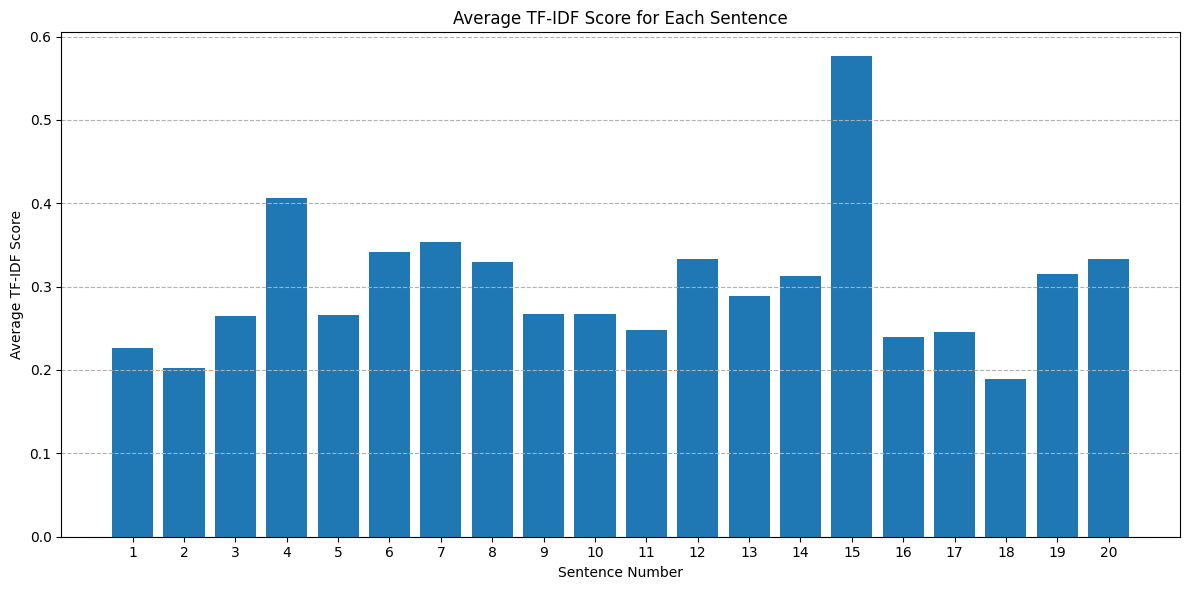


**Explanation of the Histogram :**
Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.

The histogram above is like a bar chart that shows this score for each sentence:
- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.
- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.

**What does the height of the bar tell us?**
- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.
- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less c

In [8]:

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score and list sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token2):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)

# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Explanation:
print("\n**Explanation of the Histogram :**")
print("Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.")
print("\nThe histogram above is like a bar chart that shows this score for each sentence:")
print("- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.")
print("- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.")
print("\n**What does the height of the bar tell us?**")
print("- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.")
print("- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main topic.")
print("\nSo, by looking at this chart, you can quickly get a sense of which sentences in the article are likely to be the most informative based on the words they use.")

# Define Threshold

In [9]:
# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.3002457472163698


In [12]:
import nltk
from nltk.tokenize import word_tokenize
import math

# Download tokenizer data if needed
nltk.download('punkt')

# Reuse English stopword removal from preprocessing cell; define fallback if needed
if 'english_stopwords' not in globals():
    from nltk.corpus import stopwords
    english_stopwords = set(stopwords.words('english'))

if 'remove_english_stopwords' not in globals():
    import re
    def remove_english_stopwords(sentence):
        tokens = re.findall(r"[A-Za-z']+", sentence.lower())
        filtered_tokens = [token for token in tokens if token not in english_stopwords]
        return " ".join(filtered_tokens)

sentences = []

for i, sent in enumerate(sent_token2):
    sentences.append(sent)

print("Tokenized sentences:")
for sent in sentences:
    print(sent)

# Initialize a list to store cleaned sentences
all_cleaned_sentences = []
for sentence in sentences:
    cleaned_sentence = remove_english_stopwords(sentence)
    all_cleaned_sentences.append(cleaned_sentence)

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "world" in each sentence
tfidf_scores = {}
for i, sentence in enumerate(sentences):
    cleaned_sentence = remove_english_stopwords(sentence)
    tf = calculate_tf("world", cleaned_sentence)
    idf = calculate_idf("world", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "world" in each sentence
print("TF-IDF Score for 'world' in each cleaned sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "world" across all cleaned sentences
overall_idf_world = calculate_idf("world", all_cleaned_sentences)
print(f"\nOverall IDF for 'world': {overall_idf_world:.4f}")

Tokenized sentences:

Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
“We’ve shown over the past 12 months we are the best team in the world.
Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
“To win these five trophies – for me, the five biggest prizes available to us – is incredible.
I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
I couldn’t

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Frans\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
#threshold = sum(sent_scores)/len(sent_scores) # Average of Sentence Scores
#threshold

np.float64(0.22305438878724734)

# Get Sentences

In [14]:
# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

# Final summary initialization
final_summ = ""

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token2[index]
        print(f"- {sent_token2[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.3002457472163698

**Summary Sentences (above or equal to the threshold):**
- “We’ve shown over the past 12 months we are the best team in the world.
- “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
- I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
- I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.
- Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
- City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.
- “As a manager it is what I am most proud of; that we are always there.
- The champion heads back to England where it faces a tough title defence in the Premier League.
- It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.

*

In [16]:
import nltk
from nltk.tokenize import word_tokenize
import math

# Ensure tokenizer is available
nltk.download('punkt')

# Reuse English stopword setup; define fallback if needed
if 'english_stopwords' not in globals():
    from nltk.corpus import stopwords
    english_stopwords = set(stopwords.words('english'))

if 'remove_english_stopwords' not in globals():
    import re
    def remove_english_stopwords(sentence):
        tokens = re.findall(r"[A-Za-z']+", sentence.lower())
        filtered_tokens = [token for token in tokens if token not in english_stopwords]
        return " ".join(filtered_tokens)

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "world" in each sentence
tfidf_scores = {}
all_cleaned_sentences = []

for i, sentence in enumerate(sentences):
    cleaned_sentence = remove_english_stopwords(sentence)
    all_cleaned_sentences.append(cleaned_sentence)
    tf = calculate_tf("world", cleaned_sentence)
    idf = calculate_idf("world", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "world" in each sentence
print("TF-IDF Score for 'world' in each cleaned sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "world" across all cleaned sentences
overall_idf_world = calculate_idf("world", all_cleaned_sentences)
print(f"\nOverall IDF for 'world': {overall_idf_world:.4f}")

# Direct approach using scikit-learn with English stop words
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(sentences)
feature_names = vectorizer.get_feature_names_out()

try:
    world_index = list(feature_names).index("world")
    print("\nTF-IDF Score for 'world' using TfidfVectorizer:")
    for i, sentence in enumerate(sentences):
        tfidf = tfidf_matrix[i, world_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'world' not found in the vocabulary after English stop word removal by TfidfVectorizer.")

TF-IDF Score for 'world' in each cleaned sentence:
Sentence 1: 0.0000
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.1155
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000
Sentence 16: 0.0000
Sentence 17: 0.0000
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0000

Overall IDF for 'world': 2.3026

TF-IDF Score for 'world' using TfidfVectorizer:
Sentence 1: 0.3790
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.3253
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000
Sentence 16: 0.0000
Sentence 17: 0.0000
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0000


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Frans\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [17]:
final_summ

' “We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”\n\nIt took just 40 seconds for Manchester City to take the lead. Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range. City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year. “As a manager it is what I am most proud of; that we are always there. The champion heads back to England where it faces a tough title defence in the Premier League. It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.'

In [18]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores) :
  if (data >= (threshold)) :
    final_summ = final_summ + " " + sent_token2[index]
    print("- ", sent_token2[index])

-  “We’ve shown over the past 12 months we are the best team in the world.
-  “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
-  I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
-  I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.
-  Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
-  City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.
-  “As a manager it is what I am most proud of; that we are always there.
-  The champion heads back to England where it faces a tough title defence in the Premier League.
-  It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.


# Summarization Result

In [19]:
final_summ

' “We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”\n\nIt took just 40 seconds for Manchester City to take the lead. Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range. City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year. “As a manager it is what I am most proud of; that we are always there. The champion heads back to England where it faces a tough title defence in the Premier League. It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.'